In [2]:
!pip install numpy scipy pillow matplotlib


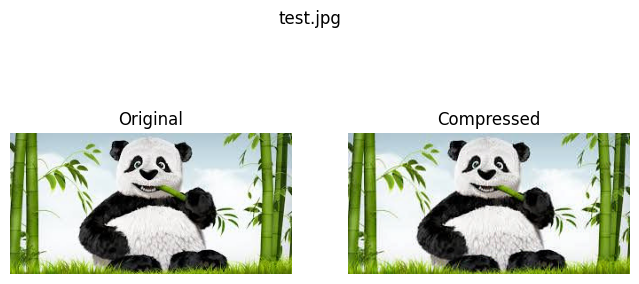

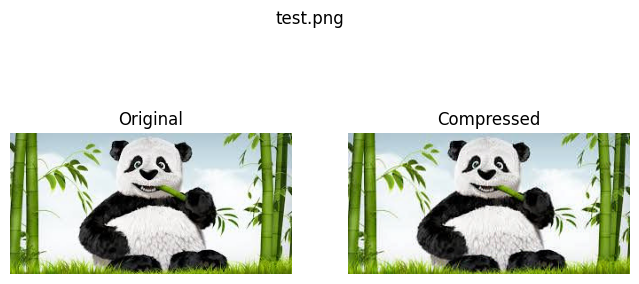

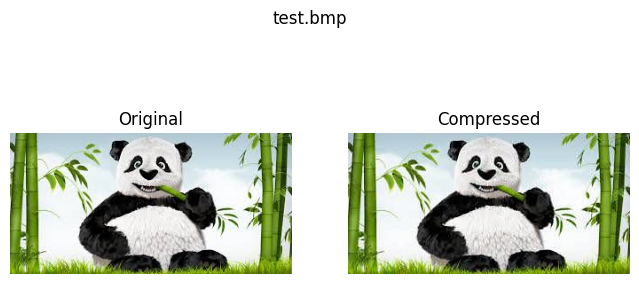


FORMAT | ORIGINAL KB | COMPRESSED KB | RATIO | PSNR
['test.jpg', 10.74, np.float64(63.27), np.float64(0.17), np.float64(33.04)]
['test.png', 99.06, np.float64(63.27), np.float64(1.57), np.float64(33.04)]
['test.bmp', 197.56, np.float64(63.27), np.float64(3.12), np.float64(33.04)]


In [9]:
import numpy as np
from scipy.fftpack import dct, idct
from PIL import Image
import matplotlib.pyplot as plt
import os

# -----------------------------
# Quantization Table
# -----------------------------
Q = np.array([
    [16,11,10,16,24,40,51,61],
    [12,12,14,19,26,58,60,55],
    [14,13,16,24,40,57,69,56],
    [14,17,22,29,51,87,80,62],
    [18,22,37,56,68,109,103,77],
    [24,35,55,64,81,104,113,92],
    [49,64,78,87,103,121,120,101],
    [72,92,95,98,112,100,103,99]
], dtype=np.float32)

# -----------------------------
# DCT Functions
# -----------------------------
def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

# -----------------------------
# Quantization
# -----------------------------
def quantize(block, quality):
    if quality < 50:
        scale = 5000 / quality
    else:
        scale = 200 - 2 * quality

    q_scaled = np.floor((Q * scale + 50) / 100).clip(1,255)
    return np.round(block / q_scaled)

def dequantize(block, quality):
    if quality < 50:
        scale = 5000 / quality
    else:
        scale = 200 - 2 * quality

    q_scaled = np.floor((Q * scale + 50) / 100).clip(1,255)
    return block * q_scaled

# -----------------------------
# Compression
# -----------------------------
def compress_channel(channel, quality):
    h, w = channel.shape
    pad_h = (8 - h % 8) % 8
    pad_w = (8 - w % 8) % 8

    padded = np.pad(channel, ((0,pad_h),(0,pad_w)), mode='edge').astype(np.float32)
    ph, pw = padded.shape

    compressed = np.zeros((ph,pw))

    for i in range(0, ph, 8):
        for j in range(0, pw, 8):
            block = padded[i:i+8, j:j+8] - 128
            d = dct2(block)
            q = quantize(d, quality)
            compressed[i:i+8, j:j+8] = q

    return compressed, pad_h, pad_w

# -----------------------------
# Decompression
# -----------------------------
def decompress_channel(comp, pad_h, pad_w, quality):
    ph, pw = comp.shape
    recon = np.zeros((ph,pw))

    for i in range(0, ph, 8):
        for j in range(0, pw, 8):
            block = comp[i:i+8, j:j+8]
            d = dequantize(block, quality)
            r = idct2(d) + 128
            recon[i:i+8, j:j+8] = r

    h = ph - pad_h
    w = pw - pad_w

    return np.clip(recon[:h, :w], 0, 255).astype(np.uint8)

# -----------------------------
# Full Image
# -----------------------------
def compress_image(img, quality=50):
    comps, pads = [], []
    for i in range(3):
        c, ph, pw = compress_channel(img[:,:,i], quality)
        comps.append(c)
        pads.append((ph,pw))
    return comps, pads

def decompress_image(comps, pads, quality=50):
    channels = []
    for i in range(3):
        ch = decompress_channel(comps[i], pads[i][0], pads[i][1], quality)
        channels.append(ch)
    return np.stack(channels, axis=2)

# -----------------------------
# PSNR
# -----------------------------
def psnr(original, recon):
    mse = np.mean((original - recon)**2)
    if mse == 0:
        return 100
    return 10 * np.log10((255**2)/mse)

# -----------------------------
# MAIN FUNCTION (NO ARRAY OUTPUT)
# -----------------------------
def process_image(image_path, quality=50):
    img = np.array(Image.open(image_path).convert("RGB"))


    original_size = os.path.getsize(image_path)/1024

    comps, pads = compress_image(img, quality)
    recon = decompress_image(comps, pads, quality)

    nonzero = sum(np.count_nonzero(c) for c in comps)
    comp_size = (nonzero*2)/1024
    ratio = original_size / comp_size
    p = psnr(img, recon)

    return original_size, comp_size, ratio, p, recon, img

# -----------------------------
# RUN FOR JPG, PNG, BMP (LIKE PAPER)
# -----------------------------
files = ["test.jpg", "test.png", "test.bmp"]

results = []

for f in files:
    orig, comp, ratio, p, recon, img = process_image(f, quality=50)

    results.append([f, round(orig,2), round(comp,2), round(ratio,2), round(p,2)])

    # Show images
    plt.figure(figsize=(8,4))
    plt.suptitle(f)

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title("Compressed")
    plt.imshow(recon)
    plt.axis('off')

    plt.show()

# -----------------------------
# PRINT RESULTS TABLE
# -----------------------------
print("\nFORMAT | ORIGINAL KB | COMPRESSED KB | RATIO | PSNR")
for r in results:
    print(r)


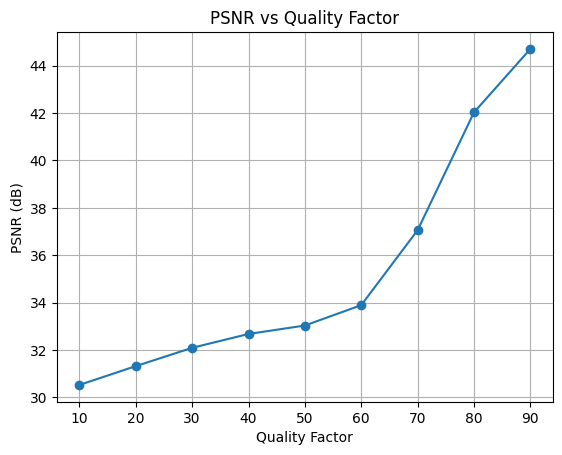

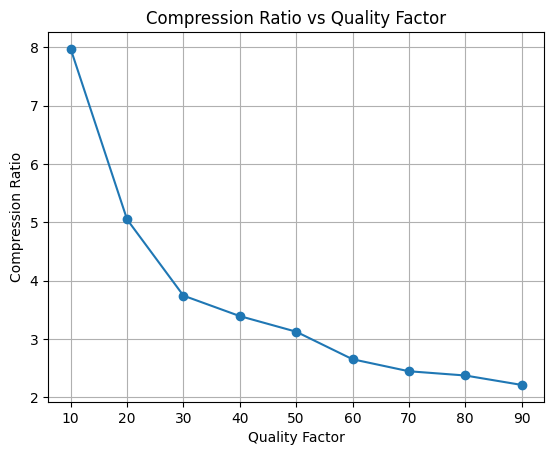

In [10]:
qualities = list(range(10, 100, 10))

psnr_vals = []
ratio_vals = []

image_path = "test.bmp"   # BEST to use BMP for paper

for q in qualities:
    orig, comp, ratio, p, recon, img = process_image(image_path, quality=q)

    psnr_vals.append(p)
    ratio_vals.append(ratio)

# -----------------------------
# GRAPH 1: PSNR vs Quality
# -----------------------------
plt.figure()
plt.plot(qualities, psnr_vals, marker='o')
plt.title("PSNR vs Quality Factor")
plt.xlabel("Quality Factor")
plt.ylabel("PSNR (dB)")
plt.grid()
plt.show()

# -----------------------------
# GRAPH 2: Compression Ratio vs Quality
# -----------------------------
plt.figure()
plt.plot(qualities, ratio_vals, marker='o')
plt.title("Compression Ratio vs Quality Factor")
plt.xlabel("Quality Factor")
plt.ylabel("Compression Ratio")
plt.grid()
plt.show()
